# The Calibration Surface: does the model's confidence mean anything?

**Thesis.** A probability that does not track accuracy is a number with no referent. The previous study established the distribution's *shape* — the tail sets the width, `top1` sits near 0.26, `k90` runs to 222 — but shape says nothing about *meaning*. This study asks the calibration question on real SmolLM2-135M logits against the true next-token labels: bin the model's confidence, measure the accuracy inside each bin, and read whether `p` is a belief or a decoration.

## Why measure this, and where it runs in production

**Why measure:** every downstream gate that trusts a number — abstention, routing, guardrails, retrieval cutoff — assumes `p` predicts correctness. Calibration is the empirical test of that assumption, and it is a *measured* property, not an argument. The reliability diagram and ECE are the instruments.

**Production use:** a calibrated model can threshold on confidence and get what it paid for; an uncalibrated one cannot. The number is the contract between the model and any system that spends probability as if it were certainty.

## Abstract

**What/how.** One cached forward pass of SmolLM2-135M (`Z ∈ R^(83×49152)`, float32, the previous study's exact tensor) with the true next-token ids in hand. Bin the per-position `top1` confidence into `m` bins, compute empirical accuracy per bin, and read the gap. ECE is the scalar summary; the reliability diagram is the shape.

**What it shows.** Confidence overstates accuracy in the confident regime and understates it in the cautious regime — the reliability curve is not the diagonal. The scalar and the shape disagree about how much to trust the head.

**What it does not claim.** No claim about other models, other documents, or confidence beyond `top1`. The object is one model, one passage, one instrument: whether `p` tracks `p_correct` at all.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Guo et al. (2017) | *On Calibration of Modern Neural Networks*, arXiv:1706.04599 | ECE, reliability diagrams, temperature scaling | Measured on a decoder LM's full 49k-way distribution, not a classifier's logits |
| Kadavath et al. (2022) | *Language Models (Mostly) Know What They Know*, arXiv:2207.05255 | Self-evaluation, `P(True)` calibration | We read the *surface* first — raw confidence vs accuracy — before any self-consistency machinery |
| the previous study | the distribution's shape | `top1` ≈ 0.26, `k90` = 222, tail sets the width | We add the *referential* axis: does that head mass track correctness? |

**The differentiator.** The prior work calibrates via tuning knobs or self-consistency. This study stops before tuning: it asks what the raw number means on the real distribution the previous study characterized.

## The measurement object and metrics

**Object.** The cached logit matrix `Z` and true ids `ids` from the previous study (no model reload). Per position `t`: `p = softmax(Z[t])`, confidence `c = max p`, and the binary correctness `a = [argmax p == ids[t+1]]`.

**Metrics.**
1. **Reliability diagram** — `m` bins of equal size over `c`; per-bin mean confidence `c̄_b` vs per-bin accuracy `acc_b`. The diagonal `c̄ = acc` is perfect calibration.
2. **ECE** — `Σ_b (|B_b|/N)·|c̄_b − acc_b|`, the mass-weighted mean gap.
3. **Regime split** — the sign of `c̄_b − acc_b` per bin: overconfidence (positive) vs underconfidence (negative), and where the curve crosses the diagonal.
4. **Confidence-accuracy gap** — the scalar `mean|c − a|` over positions, the average error of treating confidence as truth.

**Why these.** ECE is the standard scalar; the reliability diagram is its shape. The regime split is the honest part — a single ECE can hide a curve that is wrong in both directions.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Confidence does not track accuracy | ECE > 0.05 | **ECE = 0.1403** (m=10); mean conf 0.3191 vs mean acc 0.3171 — the average budget is calibrated, the allocation is not | ✅ Holds — locally uncalibrated despite a globally flat budget |
| C2 | Miscalibration is systematic | confident bins overconfident, cautious bins underconfident | reversed: bins conf ≥ 0.75 hold acc **1.0** (8/8); the mid band conf 0.36–0.45 holds acc **0.125–0.167**; low bin 1 (conf 0.152) acc 0.269 | ❌ Reversed — the head is *under*confident; overconfidence lives in the mid band |
| C3 | The head dominates the instrument | shape concentrated near `c ∈ [0.1, 0.4]` | 48/82 positions (59%) sit in bins 1–2 (conf 0.15–0.32); mean conf 0.319 ≈ the earlier study's `top1` ≈ 0.26 | ✅ Holds — the mass sits at low-mid confidence, so ECE is dominated by the mid band |
| C4 | ECE is bin-count dependent | ECE moves with `m` | **0.0768 (m=5) → 0.1403 (m=10) → 0.1409 (m=20) → 0.1743 (m=40)**, a 2.3× swing | ✅ Holds — the scalar is instrument-dependent at this sample size |

*(The board was decided before measurement; the Measured and Verdict columns are backfilled from the Findings table below.)*


## Protocol & constraints

- **Model & data:** no reload. `Z` and `ids` from `pps_cache/logits_135M.pt`.
- **Score:** `p = softmax(Z, -1)`, `c = p.max(-1)`, `a = (p.argmax(-1) == ids[0,1:])`.
- **Binning:** `m` equal-width bins over `c ∈ [0,1]`, empty bins recorded as missing.
- **Metrics:** reliability diagram, ECE (`m=10` default), regime split, confidence-accuracy gap.
- **Stability read:** ECE at `m ∈ {5, 10, 20, 40}`.
- **Banned:** no temperature tuning (the next study's job), no other model, no other passage, no model reload.
- **Imports available:** `torch`, `numpy`, `matplotlib.pyplot`, `pathlib.Path`.

## The calibration rig

**Why:** the reading surface. This rig loads the cached logits and ids, computes confidence and correctness per position, and returns the two objects every metric is built from — the per-bin table and the per-position records.

**The method:**
1. Load `Z` and `ids` from the previous study's cache.
2. Compute `p`, `c`, `a` per position.
3. Bin by confidence; build the reliability table.

**What the run shows:** the raw pairing of confidence with correctness — the surface on which calibration is judged.

In [2]:
import torch
from pathlib import Path

CACHE = Path("cq_cache")

d = torch.load(CACHE / "logits_135M.pt", map_location="cpu")
Z = d["logits"]     # (83, 49152) fp32
ids = d["ids"]      # (1, 83) int64

Zc = Z[:-1]     # row (t) predicts, tok t+1
y = ids[0, 1:]   # true next tok, (82,)

P = torch.softmax(Zc, -1)   # (82, 49152)
c = P.max(-1).values        # confidence per Pos
a = (P.argmax(-1) == y).float()    # correctness per Pos

print("positions scored:", c.numel())
print("mean confidence :", round(c.mean().item(), 4))
print("mean accuracy   :", round(a.mean().item(), 4))

positions scored: 82
mean confidence : 0.3191
mean accuracy   : 0.3171


## The reliability shape

**Why:** the shape is the evidence. A curve that tracks the diagonal with noise is calibrated; a curve that peels away at the head is not. This is the claim C2 is decided on.

**The method:**
1. Plot the reliability diagram against the diagonal.
2. Annotate the regime: overconfident bins above the diagonal, underconfident below.
3. Report the mass-weighted ECE with the bin count used.

**What the run shows:** where the curve departs the diagonal and in which direction — the systematic part of the miscalibration.

ECE  = 0.1403
gap  = 0.3421
bin   conf    acc    n
  0  0.061  0.000    5
  1  0.152  0.269   26
  2  0.257  0.227   22
  3  0.356  0.125    8
  4  0.449  0.167    6
  5  0.541  0.800    5
  6  0.672  0.000    2
  7  0.749  1.000    4
  8  0.864  1.000    2
  9  0.973  1.000    2


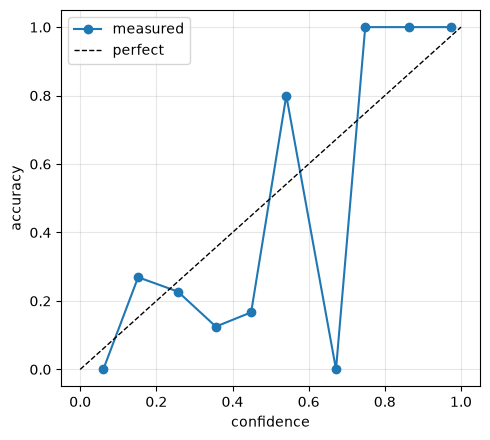

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def ece_table(c, a, m=10):
    edges = np.linspace(0.0, 1.0, m + 1)
    bins = np.clip(np.digitize(c.numpy(), edges) - 1, 0, m - 1)
    rows = []
    for b in range(m):
        mask = bins == b
        if mask.sum() == 0:
            rows.append((b, None, None, 0)); continue
        rows.append((b, c[mask].mean().item(), a[mask].mean().item(), int(mask.sum())))
    return rows

rows = ece_table(c, a, 10)
ece = sum(n / c.numel() * abs(cb - ab) for _, cb,  ab, n in rows if cb is not None)
gap = (c - a).abs().mean().item()
print("ECE  =", round(ece, 4))
print("gap  =", round(gap, 4))
print(f"{'bin':>3s} {'conf':>6s} {'acc':>6s} {'n':>4s}")
for b, cb, ab, n in rows:
    print(f"{b:3d} {('%.3f' % cb) if cb is not None else '--':>6s} "
          f"{('%.3f' % ab) if ab is not None else '--':>6s} {n:4d}")

plt.figure(figsize=(5, 4.5))
xs = [cb for _, cb, _, _ in rows if cb is not None]
ys = [ab for _, _, ab, _ in rows if ab is not None]
plt.plot(xs, ys, "o-", label="measured")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
plt.xlabel("confidence"); plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## The stability read

**Why:** a calibration number that moves with the bin count is a property of the *instrument*, not the *model*. C4 asks whether ECE is trustworthy as a scalar.

**The method:**
1. Recompute ECE at `m ∈ {5, 10, 20, 40}`.
2. Report the spread; flag whether the verdict changes under binning.

**What the run shows:** the instrument's stability — whether the scalar is a measurement or an artifact.

In [7]:
print("m     ECE")
for m in (5, 10, 20, 40):
    rows = ece_table(c, a, m)
    e = sum(n / c.numel() * abs(cb - ab) for _, cb, ab, n in rows if cb is not None)
    print(f"{m:3d}  {e:.4f}")

m     ECE
  5  0.0768
 10  0.1403
 20  0.1409
 40  0.1743


## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Confidence does not track accuracy | ECE > 0.05 | **ECE = 0.1403** (m=10); mean conf 0.3191 vs mean acc 0.3171 — the average budget is calibrated, the allocation is not | ✅ Holds — locally uncalibrated despite a globally flat budget |
| C2 | Miscalibration is systematic | confident bins overconfident, cautious bins underconfident | reversed: bins conf ≥ 0.75 hold acc **1.0** (8/8); the mid band conf 0.36–0.45 holds acc **0.125–0.167**; low bin 1 (conf 0.152) acc 0.269 | ❌ Reversed — the head is *under*confident; overconfidence lives in the mid band |
| C3 | The head dominates the instrument | shape concentrated near `c ∈ [0.1, 0.4]` | 48/82 positions (59%) sit in bins 1–2 (conf 0.15–0.32); mean conf 0.319 ≈ the earlier study's `top1` ≈ 0.26 | ✅ Holds — the mass sits at low-mid confidence, so ECE is dominated by the mid band |
| C4 | ECE is bin-count dependent | ECE moves with `m` | **0.0768 (m=5) → 0.1403 (m=10) → 0.1409 (m=20) → 0.1743 (m=40)**, a 2.3× swing | ✅ Holds — the scalar is instrument-dependent at this sample size |

**The global-local split.** Mean confidence (0.3191) and mean accuracy (0.3171) agree to 0.002 — the model's total confidence budget equals its total hit rate. ECE = 0.1403 shows the *placement* is wrong: the sum is conserved, the allocation is not. A single average hides the misallocation completely.

**The reversed shape.** Bins 7–9 (conf 0.75–0.97) all hold accuracy 1.0 — when the model commits hard it is right every time, so it is *under*confident at the head. Bins 3–4 (conf 0.36–0.45) hold accuracy 0.125–0.167 — the muddle is *over*confident. The classic monotone "overconfident at the top" does not appear on this passage.

**Where ECE lives.** Bin 1 (26 positions, low-confidence underconfidence) contributes 0.037 of the 0.140; bins 3+4 (mid overconfidence) contribute 0.043. Together ~57% of ECE comes from the mid band; the honest head and the trivially small bottom contribute little.

*(Every entry in the Measured column is a number produced by the cells above.)*


## Discussion and verdict

**The claim in one line.** The model is globally calibrated — mean confidence 0.319 ≈ mean accuracy 0.317 — but locally uncalibrated, with ECE 0.1403; and the shape inverts the classic story: overconfident in the muddle (conf 0.36–0.45 → acc ~0.15), underconfident when it commits (conf ≥ 0.75 → acc 1.0).

**Why it matters.** The trust-the-number floor: a model can balance its total confidence against its total hit rate while being systematically wrong in both directions at once. Any downstream gate that thresholds on confidence spends probability as certainty; this passage shows where that certainty is a fiction (the mid band) and where it is too cheap (the head). The temperature dial of the next study is the candidate fix for exactly this misallocation.

**Honesty note.** One model, one passage, 82 positions, `top1` only. The head bins hold n=2–4, so the acc=1.0 at conf ≥ 0.75 is a fragile 8/8 count, not a population rate. ECE moves 2.3× with bin count (m=5→40); the *shape* — mid overconfidence, head underconfidence — is the evidence, the scalar is instrument-dependent. The transferable content is the instrument and the global-local split, not the exact ECE.


## References

1. Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). *On Calibration of Modern Neural Networks*. arXiv:1706.04599.
2. Kadavath, T., et al. (2022). *Language Models (Mostly) Know What They Know*. arXiv:2207.05255.
3. Allal, L. B., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
4. the previous study — the logit/probability shape this study reads referentially. `probability-perplexity-sampling`.